In [1]:
import re
import random
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

random.seed(42)
np.random.seed(42)

In [2]:
positive_templates = [
    "I absolutely loved this {noun}, it was {pos_adj} from start to finish.",
    "What a {pos_adj} {noun}, I would watch it again.",
    "The {noun} was {pos_adj} and truly {pos_adj2}.",
    "An {pos_adj} experience, the {noun} exceeded my expectations.",
    "This {noun} is {pos_adj}, the acting was {pos_adj2}.",
    "I can't stop thinking about how {pos_adj} this {noun} was.",
    "Highly recommend this {noun}, it was {pos_adj} and {pos_adj2}.",
    "The plot of this {noun} was {pos_adj}, and the ending was {pos_adj2}.",
    "Such a {pos_adj} {noun}, everything about it felt {pos_adj2}.",
    "This is one of the most {pos_adj} {noun}s I have ever seen, truly {pos_adj2}.",
]

negative_templates = [
    "I really disliked this {noun}, it was {neg_adj} from start to finish.",
    "What a {neg_adj} {noun}, I would not watch it again.",
    "The {noun} was {neg_adj} and honestly {neg_adj2}.",
    "A {neg_adj} experience, the {noun} fell far below my expectations.",
    "This {noun} is {neg_adj}, the acting was {neg_adj2}.",
    "I regret watching this {noun}, it was {neg_adj}.",
    "Would not recommend this {noun}, it was {neg_adj} and {neg_adj2}.",
    "The plot of this {noun} was {neg_adj}, and the ending was {neg_adj2}.",
    "Such a {neg_adj} {noun}, everything about it felt {neg_adj2}.",
    "This is one of the most {neg_adj} {noun}s I have ever seen, truly {neg_adj2}.",
]

nouns = ["movie", "film", "show", "documentary", "series", "performance", "story", "production"]
pos_adjs = ["fantastic", "brilliant", "amazing", "wonderful", "delightful", "outstanding", "superb", "engaging", "charming", "excellent"]
neg_adjs = ["terrible", "boring", "awful", "dreadful", "disappointing", "dull", "mediocre", "poorly made", "tedious", "unwatchable"]

def generate_samples(templates, adj_list, n):
    samples = []
    for _ in range(n):
        t = random.choice(templates)
        s = t.format(
            noun=random.choice(nouns),
            pos_adj=random.choice(adj_list),
            pos_adj2=random.choice(adj_list),
            neg_adj=random.choice(adj_list),
            neg_adj2=random.choice(adj_list),
        )
        samples.append(s)
    return samples

pos_samples = generate_samples(positive_templates, pos_adjs, 150)
neg_samples = generate_samples(negative_templates, neg_adjs, 150)

texts = pos_samples + neg_samples
labels = [1] * len(pos_samples) + [0] * len(neg_samples)

df = pd.DataFrame({"text": texts, "label": labels})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (300, 2)


,text,label
0,"I regret watching this documentary, it was ter...",0
1,"This production is unwatchable, the acting was...",0
2,"I regret watching this production, it was drea...",0
3,"What a wonderful movie, I would watch it again.",1
4,"Would not recommend this show, it was tedious ...",0


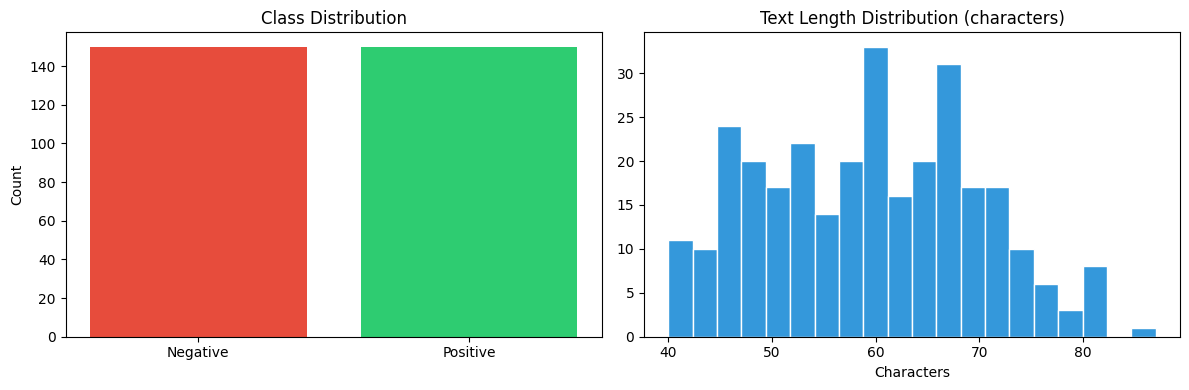

label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [3]:
# Class balance
label_counts = df["label"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Negative", "Positive"], label_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")

df["char_len"] = df["text"].str.len()
axes[1].hist(df["char_len"], bins=20, color="#3498db", edgecolor="white")
axes[1].set_title("Text Length Distribution (characters)")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print(df["label"].value_counts(normalize=True).rename("proportion"))

In [4]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)          # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(8)

,text,clean_text
0,"I regret watching this documentary, it was ter...",regret watching documentary terrible
1,"This production is unwatchable, the acting was...",production unwatchable acting poorly
2,"I regret watching this production, it was drea...",regret watching production dreadful
3,"What a wonderful movie, I would watch it again.",wonderful movie watch
4,"Would not recommend this show, it was tedious ...",recommend tedious dreadful
5,"What a unwatchable movie, I would not watch it...",unwatchable movie watch
6,"The plot of this documentary was dull, and the...",plot documentary dull ending tedious
7,"What a excellent series, I would watch it again.",excellent series watch


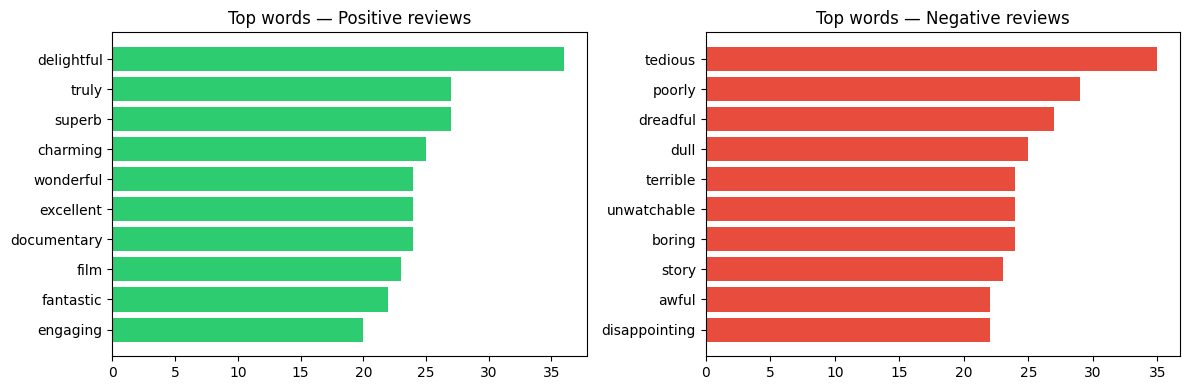

In [5]:
from collections import Counter

def top_words(subset_df, n=10):
    words = " ".join(subset_df["clean_text"]).split()
    return Counter(words).most_common(n)

pos_top = top_words(df[df.label == 1])
neg_top = top_words(df[df.label == 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh([w for w, _ in pos_top][::-1], [c for _, c in pos_top][::-1], color="#2ecc71")
axes[0].set_title("Top words — Positive reviews")
axes[1].barh([w for w, _ in neg_top][::-1], [c for _, c in neg_top][::-1], color="#e74c3c")
axes[1].set_title("Top words — Negative reviews")
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42, stratify=df["label"]
)

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Train shape: {X_train_tfidf.shape}")
print(f"Test shape:  {X_test_tfidf.shape}")

Train shape: (240, 473)
Test shape:  (60, 473)


In [7]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
}

results = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name:22s} accuracy: {acc:.3f}")

best_name = max(results, key=results.get)
print(f"\nBest baseline model: {best_name}")

Naive Bayes            accuracy: 1.000
Logistic Regression    accuracy: 1.000
Linear SVM             accuracy: 1.000

Best baseline model: Naive Bayes


In [8]:
param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_tfidf, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 3))

final_model = grid.best_estimator_

Best params: {'C': 1}
Best CV accuracy: 1.0


Test accuracy: 1.0

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        30
    Positive       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



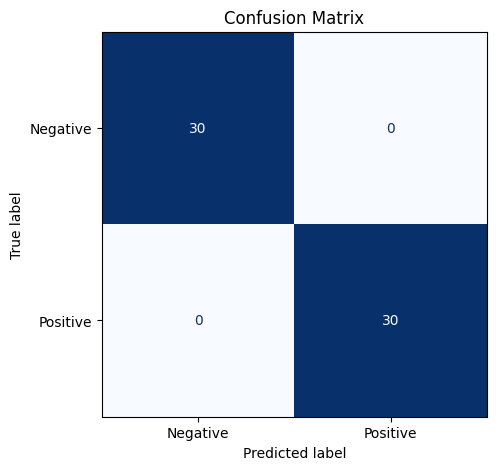

In [9]:
preds = final_model.predict(X_test_tfidf)

print("Test accuracy:", round(accuracy_score(y_test, preds), 3))
print()
print(classification_report(y_test, preds, target_names=["Negative", "Positive"]))

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix")
plt.show()

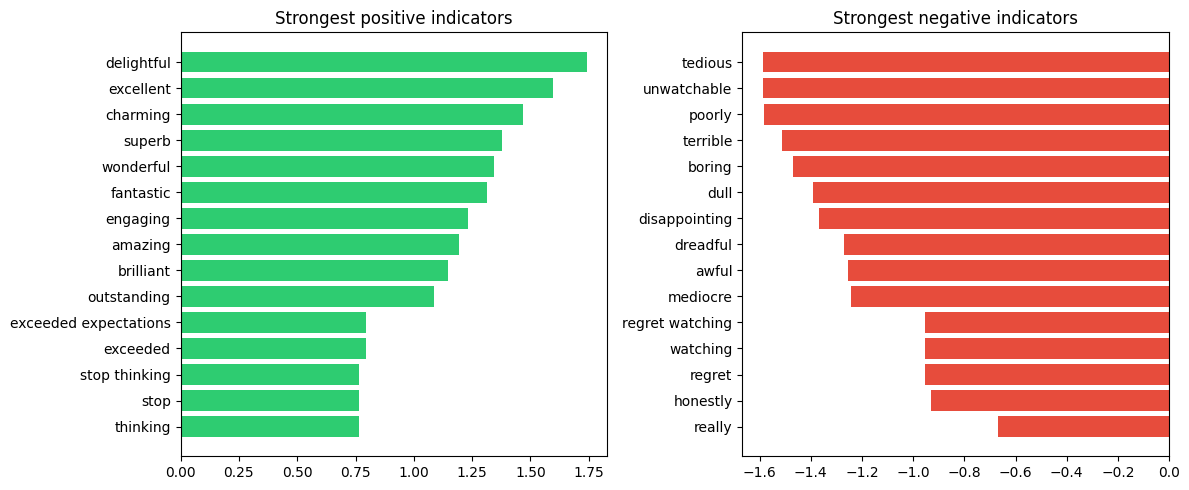

In [10]:
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = final_model.coef_[0]

top_pos_idx = np.argsort(coefs)[-15:][::-1]
top_neg_idx = np.argsort(coefs)[:15]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(feature_names[top_pos_idx][::-1], coefs[top_pos_idx][::-1], color="#2ecc71")
axes[0].set_title("Strongest positive indicators")
axes[1].barh(feature_names[top_neg_idx][::-1], coefs[top_neg_idx][::-1], color="#e74c3c")
axes[1].set_title("Strongest negative indicators")
plt.tight_layout()
plt.show()

In [11]:
with open("sentiment_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Saved sentiment_model.pkl and tfidf_vectorizer.pkl")

Saved sentiment_model.pkl and tfidf_vectorizer.pkl


In [12]:
def predict_sentiment(text: str, model=final_model, vec=vectorizer) -> dict:
    cleaned = clean_text(text)
    features = vec.transform([cleaned])
    pred = model.predict(features)[0]

    # LinearSVC / LogisticRegression: use decision_function or predict_proba if available
    if hasattr(model, "predict_proba"):
        confidence = float(np.max(model.predict_proba(features)))
    else:
        confidence = float(np.abs(model.decision_function(features))[0])

    return {
        "text": text,
        "sentiment": "Positive" if pred == 1 else "Negative",
        "confidence": round(confidence, 3),
    }

examples = [
    "This film was absolutely fantastic and I loved every moment of it.",
    "What a boring and terrible waste of time, I want my money back.",
    "The performances were engaging and the story was truly excellent.",
    "A dull, disappointing production with a mediocre script.",
]

for ex in examples:
    result = predict_sentiment(ex)
    print(f"[{result['sentiment']:8s} | conf={result['confidence']:.3f}] {ex}")

[Positive | conf=0.830] This film was absolutely fantastic and I loved every moment of it.
[Negative | conf=0.893] What a boring and terrible waste of time, I want my money back.
[Positive | conf=0.793] The performances were engaging and the story was truly excellent.
[Negative | conf=0.846] A dull, disappointing production with a mediocre script.
